# Análisis Exploratorio

Alumnos:

*   Alonso Casanova
*   Bruno Cerda



### Librerías y datos

In [4]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [5]:
!unzip OneDrive_2026-03-25.zip
!mv -f Datasets\ Tarea\ \(p├║blico\) Datos

Archive:  OneDrive_2026-03-25.zip
 extracting: Datasets Tarea (p├║blico)/competicion_ranking.json  
 extracting: Datasets Tarea (p├║blico)/competicion_rating.txt  
 extracting: Datasets Tarea (p├║blico)/wikimedia_image_embeddings.npy  
 extracting: Datasets Tarea (p├║blico)/wikimedia_item_id_to_idx.npy  
 extracting: Datasets Tarea (p├║blico)/wikimedia_train.csv  
 extracting: Datasets Tarea (p├║blico)/wikimedia_validation.csv  
 extracting: Datasets Tarea (p├║blico)/ydata_artists.txt  
 extracting: Datasets Tarea (p├║blico)/ydata_train.txt  
 extracting: Datasets Tarea (p├║blico)/ydata_val.txt  


In [6]:
yahoo_train = pd.read_csv("Datos/ydata_train.txt", sep="\t", header=None)
yahoo_train.columns = ["user_id", "artist_id", "rating"]
yahoo_train["rating"] = yahoo_train["rating"].replace(255, 0)

yahoo_artists = pd.read_csv("Datos/ydata_artists.txt", sep="\t", header=None)
yahoo_artists.columns = ["artist_id", "artist_name", "genre"]

yahoo_val = pd.read_csv("Datos/ydata_val.txt", sep="\t", header=None)
yahoo_val.columns = ["user_id", "artist_id", "rating"]
yahoo_val["rating"] = yahoo_val["rating"].replace(255, 0)

wiki_train = pd.read_csv("Datos/wikimedia_train.csv")

wiki_val = pd.read_csv("Datos/wikimedia_validation.csv")

## Datos Yahoo! Music

### Tabla con estadísticas dataset

In [7]:
number_of_users_train = yahoo_train["user_id"].nunique()
number_of_items_train = yahoo_train["artist_id"].nunique()

number_of_users_validation = yahoo_val["user_id"].nunique()
number_of_items_validation = yahoo_val["artist_id"].nunique()

number_of_ratings_train = yahoo_train.shape[0]
number_of_ratings_validation = yahoo_val.shape[0]

avg_number_of_ratings_per_user_train = yahoo_train.groupby("user_id")["rating"].count().mean()
avg_number_of_ratings_per_user_validation = yahoo_val.groupby("user_id")["rating"].count().mean()

avg_number_of_ratings_per_item_train = yahoo_train.groupby("artist_id")["rating"].count().mean()
avg_number_of_ratings_per_item_validation = yahoo_val.groupby("artist_id")["rating"].count().mean()

avg_rating_train = yahoo_train["rating"].mean()
avg_rating_validation = yahoo_val["rating"].mean()

rating_std_train = yahoo_train["rating"].std()
rating_std_validation = yahoo_val["rating"].std()

max_number_of_ratings_by_user_train = yahoo_train.groupby("user_id")["rating"].count().max()
max_number_of_ratings_by_user_validation = yahoo_val.groupby("user_id")["rating"].count().max()

max_number_of_ratings_for_item_train = yahoo_train.groupby("artist_id")["rating"].count().max()
max_number_of_ratings_for_item_validation = yahoo_val.groupby("artist_id")["rating"].count().max()

density_train = number_of_ratings_train / (number_of_users_train * number_of_items_train)
density_validation = number_of_ratings_validation / (number_of_users_validation * number_of_items_validation)


print('------------------------------ TABLA ------------------------------')
print(f'Numero de usuarios individuales: TRAIN -> {number_of_users_train} / VALIDACION -> {number_of_users_validation}')
print(f'Numero de artistas individuales: TRAIN -> {number_of_items_train} / VALIDACION -> {number_of_items_validation}')
print(f'Numero total de ratings: TRAIN -> {number_of_ratings_train} / VALIDACION -> {number_of_ratings_validation}')
print(f'Promedio rating: TRAIN -> {number_of_ratings_train} / VALIDACION -> {number_of_ratings_validation}')
print(f'Numero promedio de ratings por usuario: TRAIN -> {avg_number_of_ratings_per_user_train} / VALIDACION -> {avg_number_of_ratings_per_user_validation}')
print(f'Numero promedio de ratings por artista: TRAIN -> {avg_number_of_ratings_per_item_train} / VALIDACION -> {avg_number_of_ratings_per_item_validation}')
print(f'Rating promedio: TRAIN -> {avg_rating_train} / VALIDACION -> {avg_rating_validation}')
print(f'Rating desviacion estandar: TRAIN -> {rating_std_train} / VALIDACION -> {rating_std_validation}')
print(f'Numero maximo de ratings hecho por un usuario: TRAIN -> {max_number_of_ratings_by_user_train} / VALIDACION -> {max_number_of_ratings_by_user_validation}')
print(f'Numero maximo de ratings para un artista: TRAIN -> {max_number_of_ratings_for_item_train} / VALIDACION -> {max_number_of_ratings_for_item_validation}')
print(f'Densidad (%): TRAIN -> {np.round(density_train*100, 2)}% / VALIDACION -> {np.round(density_validation*100, 2)}%')
print('-------------------------------------------------------------------')

------------------------------ TABLA ------------------------------
Numero de usuarios individuales: TRAIN -> 2549 / VALIDACION -> 2549
Numero de artistas individuales: TRAIN -> 2631 / VALIDACION -> 2631
Numero total de ratings: TRAIN -> 534637 / VALIDACION -> 152424
Promedio rating: TRAIN -> 534637 / VALIDACION -> 152424
Numero promedio de ratings por usuario: TRAIN -> 209.7438211063162 / VALIDACION -> 59.79756767359749
Numero promedio de ratings por artista: TRAIN -> 203.20676548840746 / VALIDACION -> 57.93386545039909
Rating promedio: TRAIN -> 18.455997246730025 / VALIDACION -> 18.504717104917862
Rating desviacion estandar: TRAIN -> 30.460294179683025 / VALIDACION -> 30.519755352072558
Numero maximo de ratings hecho por un usuario: TRAIN -> 392 / VALIDACION -> 112
Numero maximo de ratings para un artista: TRAIN -> 383 / VALIDACION -> 122
Densidad (%): TRAIN -> 7.97% / VALIDACION -> 2.27%
-------------------------------------------------------------------


### Distribución: Número de ratings por usuario y artista.

In [8]:
items_per_user_train = yahoo_train.groupby("user_id")["rating"].count()
items_per_user_validation = yahoo_val.groupby("user_id")["rating"].count()

users_per_item_train = yahoo_train.groupby("artist_id")["rating"].count()
users_per_item_validation = yahoo_val.groupby("artist_id")["rating"].count()

print('Estadisticas de estas distribuciones:')

print('1. Items por usuario')

print('Train')
print(items_per_user_train.describe())
print('Validacion')
print(items_per_user_validation.describe())

print('------------------------------------')

print('2. Usuario por item')

print('Train')
print(users_per_item_train.describe())
print('Validacion')
print(users_per_item_validation.describe())

Estadisticas de estas distribuciones:
1. Items por usuario
Train
count    2549.000000
mean      209.743821
std        51.529677
min       128.000000
25%       171.000000
50%       195.000000
75%       236.000000
max       392.000000
Name: rating, dtype: float64
Validacion
count    2549.000000
mean       59.797568
std        14.730967
min        36.000000
25%        49.000000
50%        56.000000
75%        67.000000
max       112.000000
Name: rating, dtype: float64
------------------------------------
2. Usuario por item
Train
count    2631.000000
mean      203.206765
std        61.931667
min        98.000000
25%       152.500000
50%       185.000000
75%       248.500000
max       383.000000
Name: rating, dtype: float64
Validacion
count    2631.000000
mean       57.933865
std        18.754492
min        20.000000
25%        43.000000
50%        54.000000
75%        71.000000
max       122.000000
Name: rating, dtype: float64


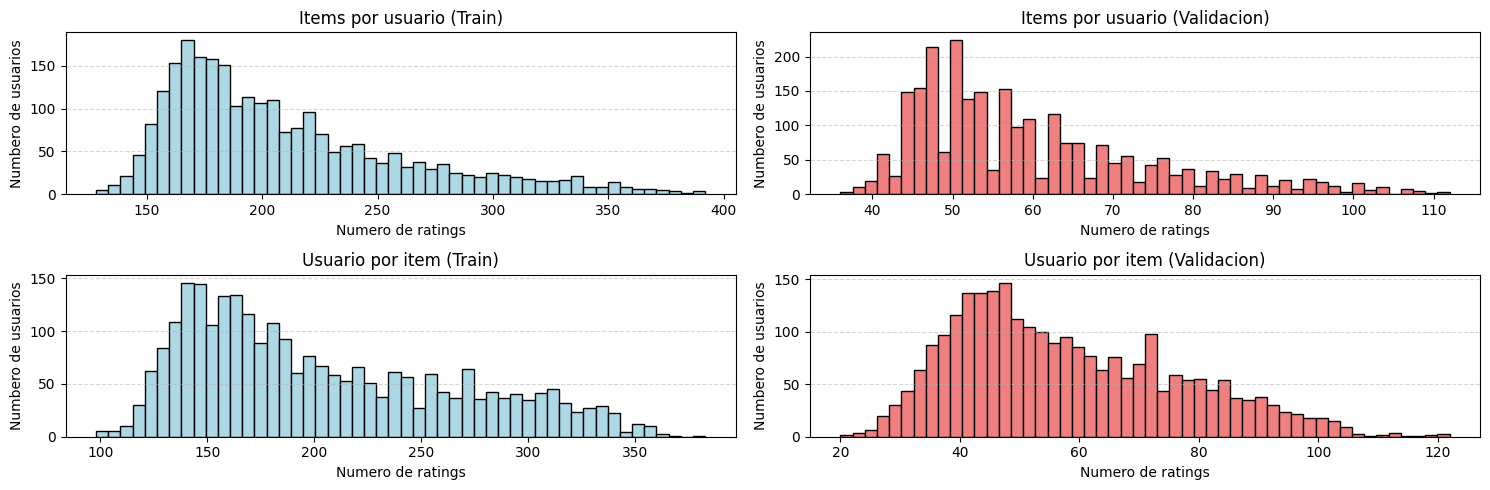

In [9]:
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(15, 5))

axes[0, 0].hist(items_per_user_train, bins=50, color='lightblue', edgecolor='black')
axes[0, 0].set_title('Items por usuario (Train)')
axes[0, 0].set_xlabel('Numero de ratings')
axes[0, 0].set_ylabel('Numbero de usuarios')
axes[0, 0].grid(axis='y', linestyle='--', alpha=0.5)

axes[0, 1].hist(items_per_user_validation, bins=50, color='lightcoral', edgecolor='black')
axes[0, 1].set_title('Items por usuario (Validacion)')
axes[0, 1].set_xlabel('Numero de ratings')
axes[0, 1].set_ylabel('Numbero de usuarios')
axes[0, 1].grid(axis='y', linestyle='--', alpha=0.5)

axes[1, 0].hist(users_per_item_train, bins=50, color='lightblue', edgecolor='black')
axes[1, 0].set_title('Usuario por item (Train)')
axes[1, 0].set_xlabel('Numero de ratings')
axes[1, 0].set_ylabel('Numbero de usuarios')
axes[1, 0].grid(axis='y', linestyle='--', alpha=0.5)

axes[1, 1].hist(users_per_item_validation, bins=50, color='lightcoral', edgecolor='black')
axes[1, 1].set_title('Usuario por item (Validacion)')
axes[1, 1].set_xlabel('Numero de ratings')
axes[1, 1].set_ylabel('Numbero de usuarios')
axes[1, 1].grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

### Distribución: Ratings promedio por usuario y artista

In [10]:
mean_rating_per_user_train = yahoo_train.groupby("user_id")["rating"].mean()
mean_rating_per_user_validation = yahoo_val.groupby("user_id")["rating"].mean()

mean_rating_per_item_train = yahoo_train.groupby("artist_id")["rating"].mean()
mean_rating_per_item_validation = yahoo_val.groupby("artist_id")["rating"].mean()

print('Estadisticas de estas distribuciones:')

print('1. Promedio rating por usuario}')

print('Train')
print(mean_rating_per_user_train.describe())
print('Validacion')
print(mean_rating_per_user_validation.describe())

print('------------------------------------')

print('2. Promedio rating por item')

print('Train')
print(mean_rating_per_item_train.describe())
print('Validacion')
print(mean_rating_per_item_validation.describe())

Estadisticas de estas distribuciones:
1. Promedio rating por usuario}
Train
count    2549.000000
mean       19.075310
std        20.700951
min         0.000000
25%         3.991071
50%        10.232323
75%        27.801205
max       100.000000
Name: rating, dtype: float64
Validacion
count    2549.000000
mean       19.144654
std        20.856834
min         0.000000
25%         3.773585
50%        10.519231
75%        28.600000
max       100.000000
Name: rating, dtype: float64
------------------------------------
2. Promedio rating por item
Train
count    2631.000000
mean       17.111894
std         7.123818
min         3.045455
25%        11.732037
50%        16.170139
75%        21.128871
max        52.146853
Name: rating, dtype: float64
Validacion
count    2631.000000
mean       17.144979
std         7.819435
min         0.727273
25%        11.331615
50%        16.232143
75%        21.928947
max        52.886598
Name: rating, dtype: float64


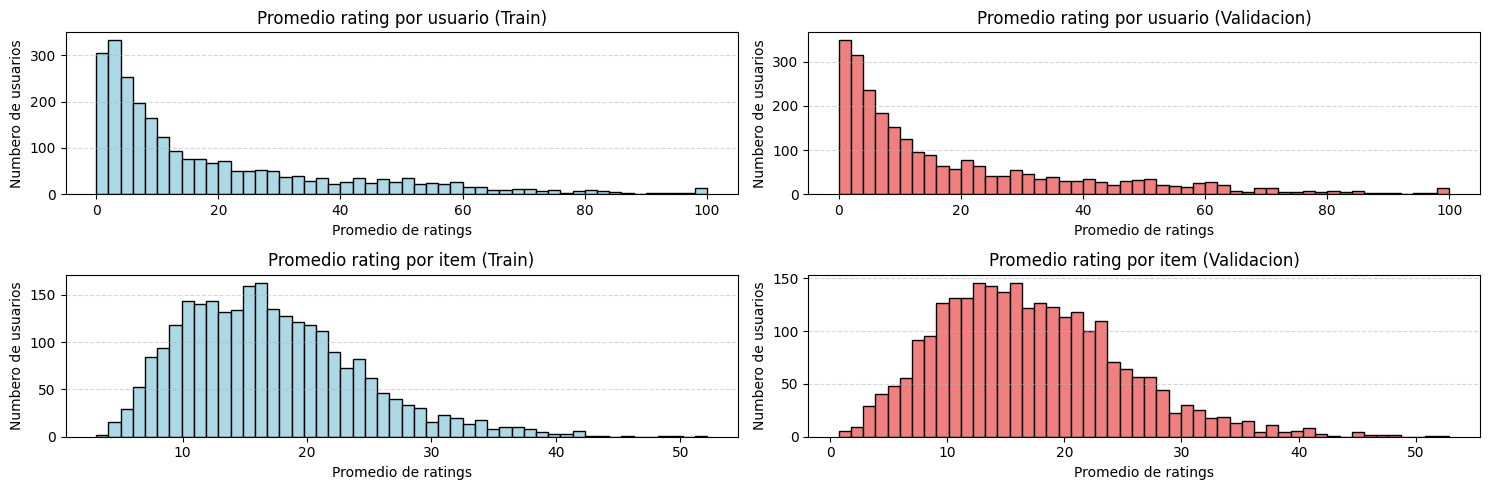

In [11]:
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(15, 5))

axes[0, 0].hist(mean_rating_per_user_train, bins=50, color='lightblue', edgecolor='black')
axes[0, 0].set_title('Promedio rating por usuario (Train)')
axes[0, 0].set_xlabel('Promedio de ratings')
axes[0, 0].set_ylabel('Numbero de usuarios')
axes[0, 0].grid(axis='y', linestyle='--', alpha=0.5)

axes[0, 1].hist(mean_rating_per_user_validation, bins=50, color='lightcoral', edgecolor='black')
axes[0, 1].set_title('Promedio rating por usuario (Validacion)')
axes[0, 1].set_xlabel('Promedio de ratings')
axes[0, 1].set_ylabel('Numbero de usuarios')
axes[0, 1].grid(axis='y', linestyle='--', alpha=0.5)

axes[1, 0].hist(mean_rating_per_item_train, bins=50, color='lightblue', edgecolor='black')
axes[1, 0].set_title('Promedio rating por item (Train)')
axes[1, 0].set_xlabel('Promedio de ratings')
axes[1, 0].set_ylabel('Numbero de usuarios')
axes[1, 0].grid(axis='y', linestyle='--', alpha=0.5)

axes[1, 1].hist(mean_rating_per_item_validation, bins=50, color='lightcoral', edgecolor='black')
axes[1, 1].set_title('Promedio rating por item (Validacion)')
axes[1, 1].set_xlabel('Promedio de ratings')
axes[1, 1].set_ylabel('Numbero de usuarios')
axes[1, 1].grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

### Distribución: Ratings

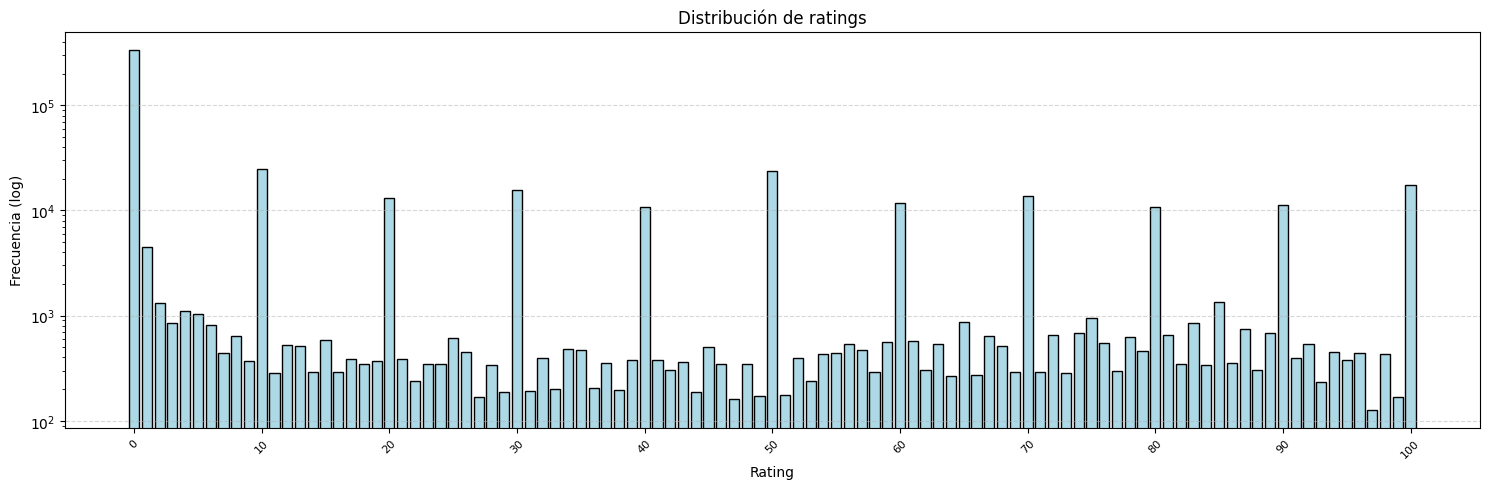

In [12]:
plt.figure(figsize=(15, 5))

ratings_amount = yahoo_train["rating"].value_counts().sort_index()

plt.bar(ratings_amount.index, ratings_amount.values, edgecolor='black', color='lightblue')
plt.yscale('log')
plt.title("Distribución de ratings")
plt.xlabel("Rating")
plt.ylabel("Frecuencia (log)")

plt.xticks(range(0, 101, 10), rotation=45, fontsize=8)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

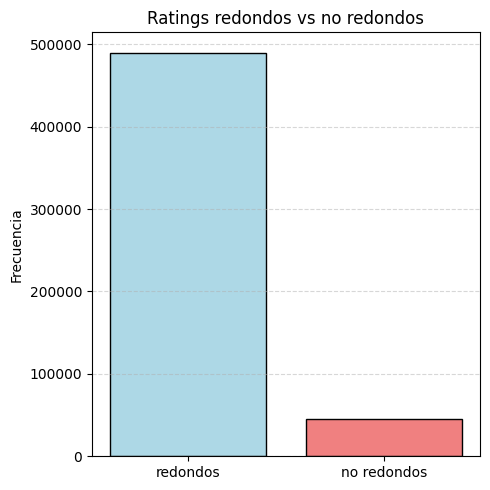

Redondos: 0.9162328832460155
No redondos: 0.08376711675398447


In [13]:
plt.figure(figsize=(5, 5))

round_ratings = yahoo_train[yahoo_train["rating"] % 10 == 0]["rating"].count()
non_round_ratings = yahoo_train[yahoo_train["rating"] % 10 != 0]["rating"].count()

frecuencia = [round_ratings, non_round_ratings]
valores = ["redondos", "no redondos"]

plt.bar(valores, frecuencia, edgecolor='black', color=['lightblue', 'lightcoral'])
plt.title("Ratings redondos vs no redondos")
plt.ylabel("Frecuencia")
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

total = round_ratings + non_round_ratings

print(f"Redondos: {round_ratings / total}")
print(f"No redondos: {non_round_ratings / total}")

### Distribución cantidad ratings por género

In [14]:
union_user_artist = yahoo_train.merge(yahoo_artists, on="artist_id")

genre_counts = union_user_artist.groupby("genre")["rating"].count()
genre_mean = union_user_artist.groupby("genre")["rating"].mean()

genre_counts_sorted = genre_counts.sort_values(ascending=False)
genre_mean_sorted = genre_mean.sort_values(ascending=False)

print(genre_counts_sorted, end="\n\n")
print(genre_mean_sorted)

genre
rock          170205
electronic    132804
pop            52452
folk           40890
country        34108
punk           28605
metal          23138
hiphop         14133
jazz            9528
blues           7996
soul            6657
latin           6153
classical       5301
reggae          1684
r&b              983
Name: rating, dtype: int64

genre
rock          21.628701
pop           19.512831
soul          19.118822
hiphop        18.400693
reggae        18.351544
metal         17.969963
jazz          17.689232
blues         17.062656
country       16.815938
electronic    16.461379
punk          16.069393
latin         15.966195
classical     15.020751
folk          14.976889
r&b           14.068159
Name: rating, dtype: float64


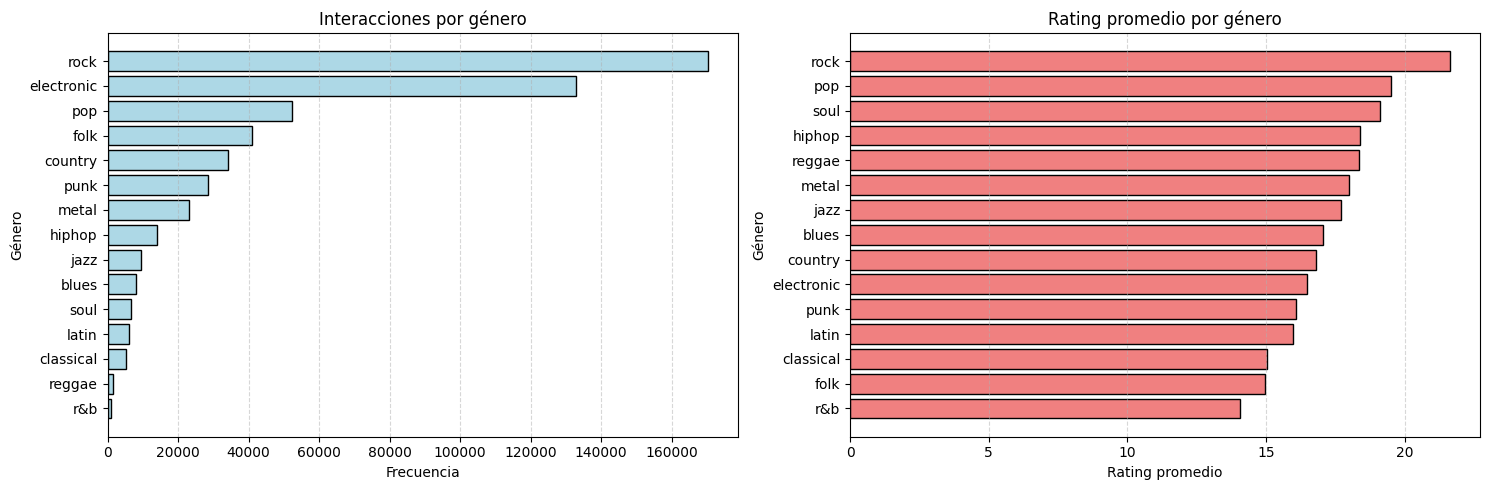

In [15]:
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(15, 5))

axes[0].barh(genre_counts_sorted.index, genre_counts_sorted.values, color='lightblue', edgecolor='black')
axes[0].set_title("Interacciones por género")
axes[0].set_xlabel("Frecuencia")
axes[0].set_ylabel("Género")
axes[0].invert_yaxis()
axes[0].grid(axis='x', linestyle='--', alpha=0.5)

axes[1].barh(genre_mean_sorted.index, genre_mean_sorted.values, color='lightcoral', edgecolor='black')
axes[1].set_title("Rating promedio por género")
axes[1].set_xlabel("Rating promedio")
axes[1].set_ylabel("Género")
axes[1].invert_yaxis()
axes[1].grid(axis='x', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

## Datos Wikimedia

In [16]:
wikimedia_train = pd.read_csv("Datos/wikimedia_train.csv", header=None)
wikimedia_train.columns = ["user_id", "item_id", "timestamp", 'evaluation']
wikimedia_train = wikimedia_train.iloc[1:]

wikimedia_validation = pd.read_csv("Datos/wikimedia_validation.csv", header=None)
wikimedia_validation.columns = ["user_id", "item_id", "timestamp", 'evaluation']
wikimedia_validation = wikimedia_validation.iloc[1:]

wikimedia_embeddings = np.load('Datos/wikimedia_image_embeddings.npy')

wikimedia_item_id_to_embedding_id = np.load('Datos/wikimedia_item_id_to_idx.npy', allow_pickle=True)

In [17]:
wikimedia_train.describe()

,user_id,item_id,timestamp,evaluation
count,67806,67806,67806,67806
unique,1079,9526,59696,2
top,2524,201203120,1380218040,False
freq,2481,24,21,67798


In [18]:
wikimedia_validation.describe()

,user_id,item_id,timestamp,evaluation
count,9694,9694,9694,9694
unique,1075,5473,8636,2
top,2524,201803100,1506325860,False
freq,351,9,17,9683


In [19]:
wikimedia_embeddings.shape

(9526, 512)

### Distribución evaluation

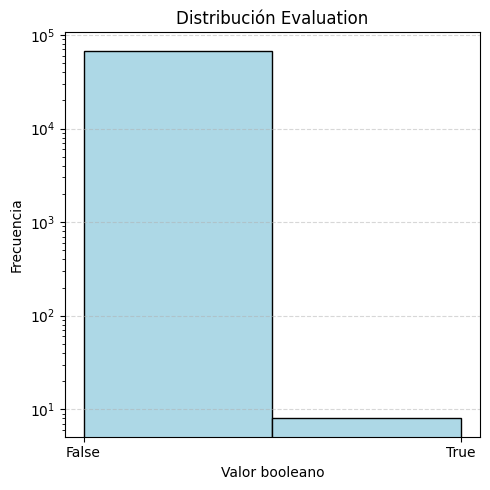

evaluation
False    67798
True         8
Name: count, dtype: int64


In [20]:
plt.figure(figsize=(5, 5))

plt.hist(wikimedia_train['evaluation'], bins=2, color='lightblue', edgecolor='black')
plt.yscale('log')
plt.title("Distribución Evaluation")
plt.xlabel("Valor booleano")
plt.ylabel("Frecuencia")
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

print(wikimedia_train['evaluation'].value_counts())

### Distribución timestamp

In [21]:
wikimedia_train['timestamp_not_unix'] = pd.to_datetime(wikimedia_train['timestamp'], unit='s')

/tmp/ipykernel_7439/1872614142.py:1: FutureWarning: The behavior of 'to_datetime' with 'unit' when parsing strings is deprecated. In a future version, strings will be parsed as datetime strings, matching the behavior without a 'unit'. To retain the old behavior, explicitly cast ints or floats to numeric type before calling to_datetime.
  wikimedia_train['timestamp_not_unix'] = pd.to_datetime(wikimedia_train['timestamp'], unit='s')


In [22]:
wikimedia_train

,user_id,item_id,timestamp,evaluation,timestamp_not_unix
1,1,200502005,1108503300,False,2005-02-15 21:35:00
2,1,200504028,1113243060,False,2005-04-11 18:11:00
3,1,200504029,1113243060,False,2005-04-11 18:11:00
4,1,200504034,1113246480,False,2005-04-11 19:08:00
5,1,200504035,1113246600,False,2005-04-11 19:10:00
...,...,...,...,...,...
67802,7395,201904158,1555263120,False,2019-04-14 17:32:00
67803,7395,201904173,1555317600,False,2019-04-15 08:40:00
67804,7395,201904201,1555897200,False,2019-04-22 01:40:00
67805,7395,201904228,1556006940,False,2019-04-23 08:09:00


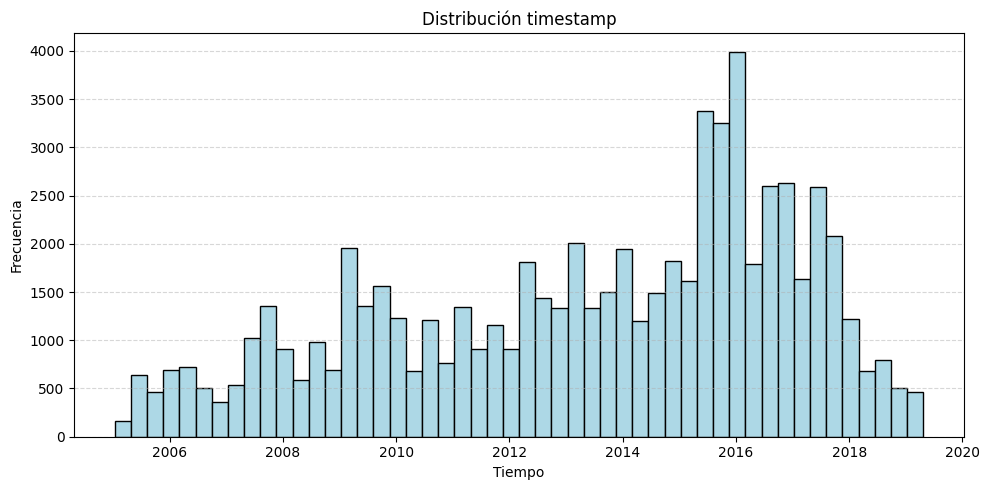

In [23]:
plt.figure(figsize=(10, 5))
plt.hist(wikimedia_train['timestamp_not_unix'], bins=50, color='lightblue', edgecolor='black')

plt.title("Distribución timestamp")
plt.xlabel("Tiempo")
plt.ylabel("Frecuencia")
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()